In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch as pt

import itertools
import collections

[(1, 1, 1, 1), (1, 1, 1, 2), (1, 1, 1, 3), (1, 1, 1, 4), (1, 1, 1, 5), (1, 1, 1, 6), (1, 1, 2, 1), (1, 1, 2, 2), (1, 1, 2, 3), (1, 1, 2, 4), (1, 1, 2, 5), (1, 1, 2, 6), (1, 1, 3, 1), (1, 1, 3, 2), (1, 1, 3, 3), (1, 1, 3, 4), (1, 1, 3, 5), (1, 1, 3, 6), (1, 1, 4, 1), (1, 1, 4, 2), (1, 1, 4, 3), (1, 1, 4, 4), (1, 1, 4, 5), (1, 1, 4, 6), (1, 1, 5, 1), (1, 1, 5, 2), (1, 1, 5, 3), (1, 1, 5, 4), (1, 1, 5, 5), (1, 1, 5, 6), (1, 1, 6, 1), (1, 1, 6, 2), (1, 1, 6, 3), (1, 1, 6, 4), (1, 1, 6, 5), (1, 1, 6, 6), (1, 2, 1, 1), (1, 2, 1, 2), (1, 2, 1, 3), (1, 2, 1, 4), (1, 2, 1, 5), (1, 2, 1, 6), (1, 2, 2, 1), (1, 2, 2, 2), (1, 2, 2, 3), (1, 2, 2, 4), (1, 2, 2, 5), (1, 2, 2, 6), (1, 2, 3, 1), (1, 2, 3, 2), (1, 2, 3, 3), (1, 2, 3, 4), (1, 2, 3, 5), (1, 2, 3, 6), (1, 2, 4, 1), (1, 2, 4, 2), (1, 2, 4, 3), (1, 2, 4, 4), (1, 2, 4, 5), (1, 2, 4, 6), (1, 2, 5, 1), (1, 2, 5, 2), (1, 2, 5, 3), (1, 2, 5, 4), (1, 2, 5, 5), (1, 2, 5, 6), (1, 2, 6, 1), (1, 2, 6, 2), (1, 2, 6, 3), (1, 2, 6, 4), (1, 2, 6, 5), (1, 2

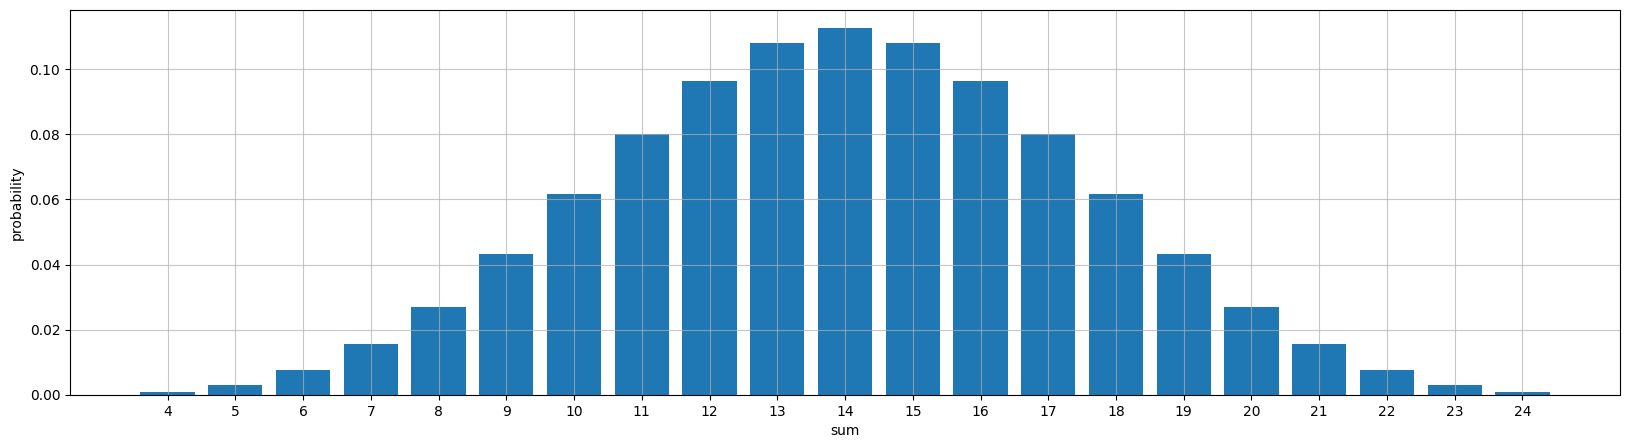

In [3]:
def count_result_and_do_the_plot(dice_num):
    dice = [1,2,3,4,5,6]
    cartesian = list(itertools.product(dice, repeat=dice_num))
    print(cartesian)
    sum_cartesian = [sum(i) for i in cartesian]
    count_sum_cartesian = collections.Counter(sum_cartesian)

    denominator = 6**dice_num
    prob = []
    sorted_count = sorted(count_sum_cartesian.keys())

    for n in range(dice_num, 6*dice_num + 1):
        prob.append(count_sum_cartesian.get(n) / denominator)


    plt.figure(figsize=(20, 5))
    plt.bar(sorted_count, prob)
    plt.xlabel('sum')
    plt.ylabel('probability')
    plt.xticks(sorted_count)
    plt.grid(alpha=0.7)
    plt.show()

count_result_and_do_the_plot(4)

In [6]:
p = np.array([2.5, 3.0])
means = {
    'A': np.array([2, 2]),
    'B': np.array([5, 3]),
    'C': np.array([1, 4])
}
covs = {
    'A': np.array([[3, 0], 
                   [0, 3]]),
    'B': np.array([[2, 1], 
                   [1, 4]]),
    'C': np.array([[16, 0], 
                   [0, 4]])
}
def calc_gaussian_pdf(x, mu, cov):
    d = len(x)
    det_cov = np.linalg.det(cov)
    inv_cov = np.linalg.inv(cov)
    
    norm_const = 1.0 / np.sqrt(((2 * np.pi) ** d) * np.abs(det_cov))
    
    diff = x - mu
    exponent = -0.5 * (diff @ inv_cov.T @ diff.T)
    
    return norm_const * np.exp(exponent)

temp_pdf = {}
w_pdf = {}
w_pdf_normalization = {}
weights = {'A': 0.30, 'B': 0.20, 'C': 0.50}
def locate_p(p, means, covs, w):
    for n in means:
        temp_pdf[n] = float(calc_gaussian_pdf(p, means[n], covs[n]))
    for k in temp_pdf:
        w_pdf[k] = temp_pdf[k] * w[k]
    
    sum_weight_pdf = sum(w_pdf.values())
    for j in w_pdf:
        w_pdf_normalization[j] =  w_pdf[j] / sum_weight_pdf

    return max(w_pdf_normalization, key=w_pdf_normalization.get), w_pdf_normalization, w_pdf


locate_p(p, means, covs, weights)


('A',
 {'A': 0.5588771177638471, 'B': 0.08724679069423721, 'C': 0.3538760915419156},
 {'A': 0.012922368296584573,
  'B': 0.0020173221021411677,
  'C': 0.008182330320764344})

<>:37: SyntaxWarning: invalid escape sequence '\e'
<>:37: SyntaxWarning: invalid escape sequence '\e'
/var/folders/s0/f874234s21s4w3fp3rnc3rfm0000gn/T/ipykernel_90179/332437708.py:37: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Density Estimation using sklearn (Manhattan, $\epsilon=1$)")
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


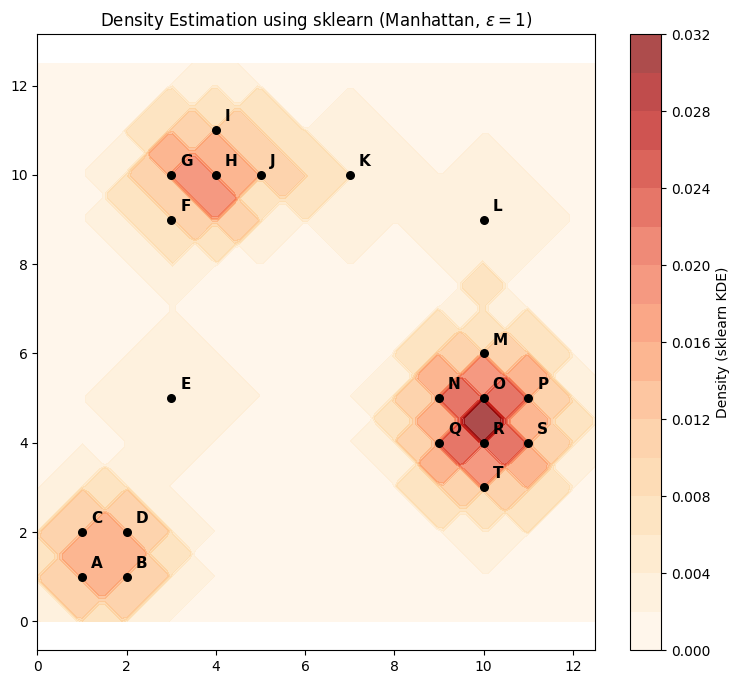

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

points = {
    'A': [1, 1], 'B': [2, 1], 'C': [1, 2], 'D': [2, 2], 'E': [3, 5],
    'F': [3, 9], 'G': [3, 10], 'H': [4, 10], 'I': [4, 11], 'J': [5, 10],
    'K': [7, 10], 'L': [10, 9], 'M': [10, 6], 'N': [9, 5], 'O': [10, 5],
    'P': [11, 5], 'Q': [9, 4], 'R': [10, 4], 'S': [11, 4], 'T': [10, 3]
}
X = np.array(list(points.values()))

# bandwidth 就是你的半徑 epsilon
# metric='manhattan' 完全符合題目要求
# kernel='tophat' 代表在半徑內的點權重都一樣 (也就是單純「計數」)
kde = KernelDensity(bandwidth=2.0, kernel='tophat', metric='manhattan')
kde.fit(X)

x_grid = np.linspace(0, 12.5, 100)
y_grid = np.linspace(0, 12.5, 100)
xx, yy = np.meshgrid(x_grid, y_grid)
grid_coords = np.c_[xx.ravel(), yy.ravel()] # 把網格攤平餵給模型

# 4. 讓模型預測密度！
# 注意：sklearn 的 score_samples 回傳的是「對數密度 (log density)」，所以要用 np.exp 轉回正常機率密度
Z = np.exp(kde.score_samples(grid_coords))
Z = Z.reshape(xx.shape) # 把攤平的預測結果折回原本的 100x100 網格形狀

plt.figure(figsize=(9, 8))
contour = plt.contourf(xx, yy, Z, levels=15, cmap='OrRd', alpha=0.7)
plt.colorbar(contour, label='Density (sklearn KDE)')

for name, coord in points.items():
    plt.scatter(coord[0], coord[1], color='black', s=30, zorder=5)
    plt.text(coord[0] + 0.2, coord[1] + 0.2, name, fontsize=11, fontweight='bold', zorder=6)

plt.title("Density Estimation using sklearn (Manhattan, $\epsilon=1$)")
plt.axis('equal')
plt.xlim(0, 12.5)
plt.ylim(0, 12.5)
plt.show()

<>:61: SyntaxWarning: invalid escape sequence '\e'
<>:61: SyntaxWarning: invalid escape sequence '\e'
/var/folders/s0/f874234s21s4w3fp3rnc3rfm0000gn/T/ipykernel_27929/545779167.py:61: SyntaxWarning: invalid escape sequence '\e'
  plt.title("3D Density Topography (Manhattan, $\epsilon=1$)", fontsize=14)


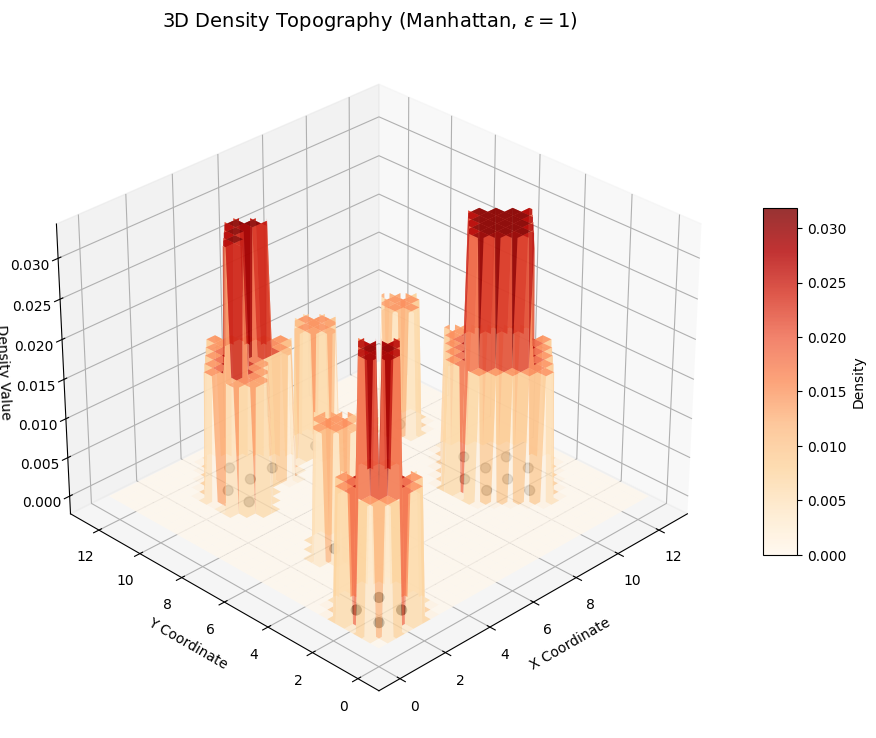

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
# 必須匯入這個 toolkit 才能畫 3D 圖
from mpl_toolkits.mplot3d import Axes3D

# --- 1. 準備資料與模型 (跟之前一模一樣) ---
points_dict = {
    'A': [1, 1], 'B': [2, 1], 'C': [1, 2], 'D': [2, 2], 'E': [3, 5],
    'F': [3, 9], 'G': [3, 10], 'H': [4, 10], 'I': [4, 11], 'J': [5, 10],
    'K': [7, 10], 'L': [10, 9], 'M': [10, 6], 'N': [9, 5], 'O': [10, 5],
    'P': [11, 5], 'Q': [9, 4], 'R': [10, 4], 'S': [11, 4], 'T': [10, 3]
}
X_train = np.array(list(points_dict.values()))

# 使用題目 (c) 的設定：固定半徑 epsilon=1, 曼哈頓距離, Tophat kernel
kde = KernelDensity(bandwidth=1.0, metric='manhattan', kernel='tophat')
kde.fit(X_train)

# --- 2. 建立 3D 網格並計算高度 Z ---
# 網格切細一點 (例如 100x100)，山峰看起來會比較平滑
x_grid = np.linspace(0, 12.5, 100)
y_grid = np.linspace(0, 12.5, 100)
xx, yy = np.meshgrid(x_grid, y_grid)

# 攤平網格餵給模型計算
grid_coords = np.c_[xx.ravel(), yy.ravel()]
# 算出 Log 密度，記得要轉回正常密度 (exp)
Z = np.exp(kde.score_samples(grid_coords))
# 把 Z reshape 回 100x100 的網格形狀
Z = Z.reshape(xx.shape)

# --- 3. 開始畫 3D 圖！ ---
fig = plt.figure(figsize=(12, 9))
# 建立一個 3D 的座標軸
ax = fig.add_subplot(111, projection='3d')

# 畫出地形表面 (Surface Plot)
# cmap='OrRd' 使用橘紅色漸層，越高越紅
# rstride, cstride 控制網格線的密度，設大一點圖會比較乾淨
surf = ax.plot_surface(xx, yy, Z, cmap='OrRd', 
                       linewidth=0, antialiased=True, rstride=3, cstride=3, alpha=0.8)

# 把原本的 20 個點畫在「地面」上 (Z=0 的位置)，當作參考
px = [p[0] for p in points_dict.values()]
py = [p[1] for p in points_dict.values()]
# zdir='z', zs=0 代表把點壓平在 Z=0 的平面上
ax.scatter(px, py, zs=0, zdir='z', s=50, c='black', depthshade=True, label='Original Points')

# 設定座標軸標籤
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Density Value')

# 設定一個漂亮的視角 (高度角 elev, 方位角 azim)
ax.view_init(elev=30, azim=-135)

# 加上顏色對照條
fig.colorbar(surf, shrink=0.5, aspect=10, label='Density')

plt.title("3D Density Topography (Manhattan, $\epsilon=1$)", fontsize=14)
plt.show()

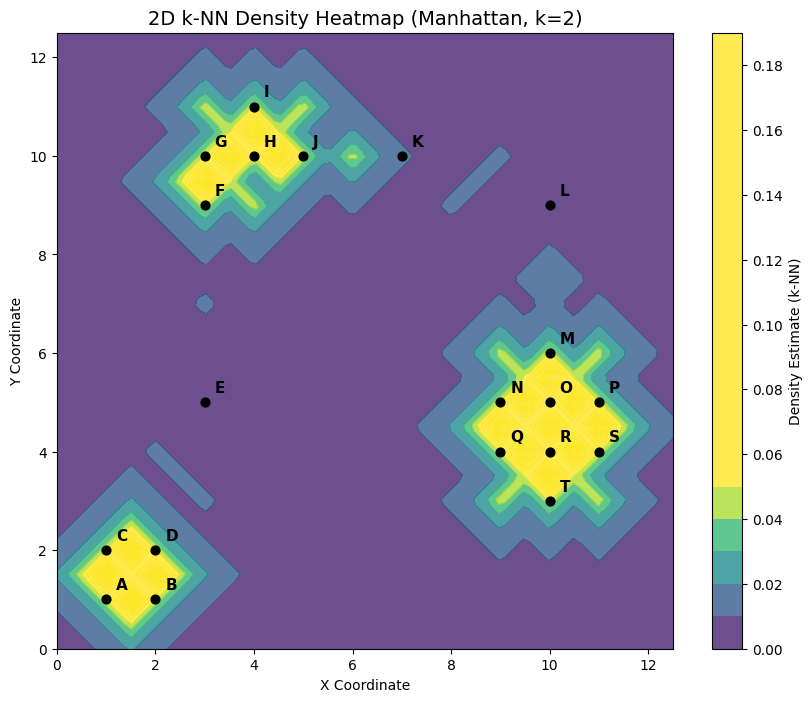

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# --- 1. 準備資料 (跟之前一模一樣) ---
points_dict = {
    'A': [1, 1], 'B': [2, 1], 'C': [1, 2], 'D': [2, 2], 'E': [3, 5],
    'F': [3, 9], 'G': [3, 10], 'H': [4, 10], 'I': [4, 11], 'J': [5, 10],
    'K': [7, 10], 'L': [10, 9], 'M': [10, 6], 'N': [9, 5], 'O': [10, 5],
    'P': [11, 5], 'Q': [9, 4], 'R': [10, 4], 'S': [11, 4], 'T': [10, 3]
}
X = np.array(list(points_dict.values()))
n_points = len(X) # 總點數 n = 20

# --- 2. 設定 k 值並訓練模型 ---
k = 2 # 我們採用題目 (b) 的設定
# 使用 NearestNeighbors 來找最近的 k 個鄰居，距離用曼哈頓
nbrs = NearestNeighbors(n_neighbors=k, metric='manhattan').fit(X)

# --- 3. 建立 2D 網格 ---
# 網格切細一點 (例如 100x100)，圖形會比較平滑
x_grid = np.linspace(0, 12.5, 100)
y_grid = np.linspace(0, 12.5, 100)
xx, yy = np.meshgrid(x_grid, y_grid)
grid_coords = np.c_[xx.ravel(), yy.ravel()]

# --- 4. 核心計算：找出半徑 r 並計算密度 Z ---
# kneighbors 會回傳每個網格點到最近 k 個鄰居的距離
distances, indices = nbrs.kneighbors(grid_coords)

# 關鍵！我們需要的半徑 r，是第 k 個鄰居的距離，也就是回傳陣列中的最後一個距離
r_kth = distances[:, -1] 

# 計算曼哈頓體積 V = 2 * r^2
# 加一個極小的數字 (1e-9) 是為了防止 r 為 0 時出現除以零的錯誤
volume = 2 * (r_kth ** 2) + 1e-9

# 帶入密度公式：Density = k / (n * Volume)
Z = k / (n_points * volume)

# 把 Z reshape 回 100x100 的網格形狀
Z = Z.reshape(xx.shape)

# --- 5. 開始畫 2D 圖！ ---
fig, ax = plt.subplots(figsize=(10, 8))

# 畫出 Heatmap (等高線熱力圖)
# cmap='viridis' 使用藍綠黃漸層，顏色越黃代表密度數字越大
# levels=20 切分 20 個顏色層級，讓漸層更細緻
# vmin, vmax 可以限制顯示的密度範圍，把極端值切掉，讓圖更好看 (這裡我們取 95% 的分位數)
vmax = np.percentile(Z, 95) 
contour = ax.contourf(xx, yy, Z, levels=20, cmap='viridis', alpha=0.8, vmax=vmax)

# 在右邊加上一條顏色對照表 (Colorbar)，讓你知道數字對應什麼顏色
cbar = fig.colorbar(contour, ax=ax, label='Density Estimate (k-NN)')

# 把原本的 20 個點跟字母畫上去，方便對照
for name, coord in points_dict.items():
    ax.scatter(coord[0], coord[1], color='black', s=40, zorder=5)
    ax.text(coord[0] + 0.2, coord[1] + 0.2, name, fontsize=11, fontweight='bold', zorder=6)

# 設定座標軸
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_title(f"2D k-NN Density Heatmap (Manhattan, k={k})", fontsize=14)

# 保持 1:1 比例，並設定範圍
ax.set_aspect('equal')
ax.set_xlim(0, 12.5)
ax.set_ylim(0, 12.5)

plt.show()

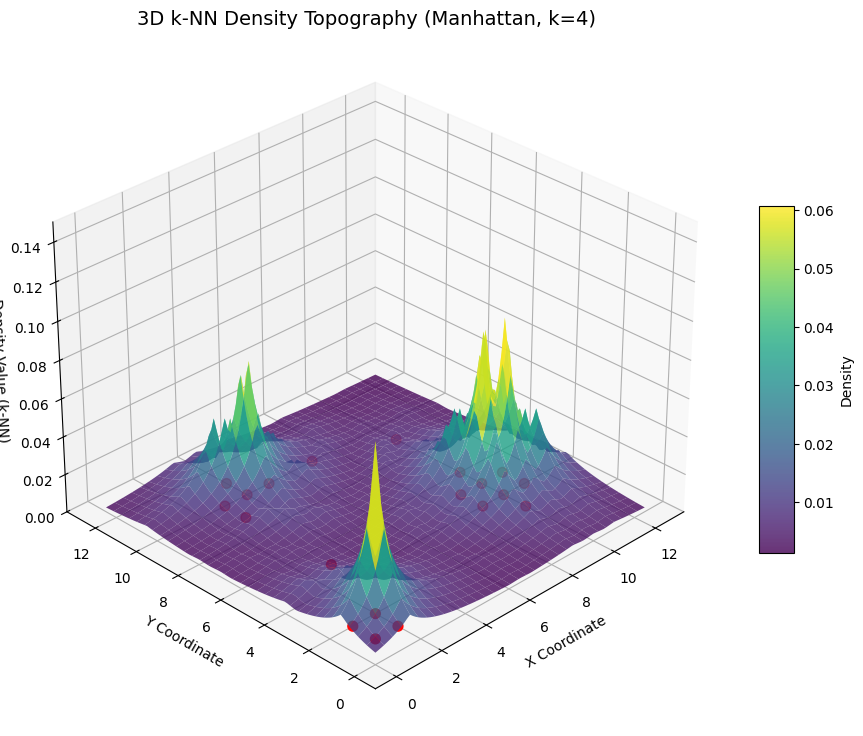

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from mpl_toolkits.mplot3d import Axes3D

# --- 1. 準備資料 ---
points_dict = {
    'A': [1, 1], 'B': [2, 1], 'C': [1, 2], 'D': [2, 2], 'E': [3, 5],
    'F': [3, 9], 'G': [3, 10], 'H': [4, 10], 'I': [4, 11], 'J': [5, 10],
    'K': [7, 10], 'L': [10, 9], 'M': [10, 6], 'N': [9, 5], 'O': [10, 5],
    'P': [11, 5], 'Q': [9, 4], 'R': [10, 4], 'S': [11, 4], 'T': [10, 3]
}
X = np.array(list(points_dict.values()))
n_points = len(X) # 總點數 n = 20

# --- 2. 設定 k 值並訓練模型 ---
k = 4  # 我們採用題目 (b) 的設定
# 使用 NearestNeighbors 來找最近的 k 個鄰居，距離用曼哈頓
nbrs = NearestNeighbors(n_neighbors=k, metric='manhattan').fit(X)

# --- 3. 建立 3D 網格 ---
# 網格切細一點，圖形更漂亮
x_grid = np.linspace(0, 12.5, 100)
y_grid = np.linspace(0, 12.5, 100)
xx, yy = np.meshgrid(x_grid, y_grid)
grid_coords = np.c_[xx.ravel(), yy.ravel()]

# --- 4. 核心計算：找出半徑 r 並計算密度 Z ---
# kneighbors 會回傳每個網格點到最近 k 個鄰居的距離
distances, indices = nbrs.kneighbors(grid_coords)

# 關鍵！我們需要的半徑 r，是第 k 個鄰居的距離，也就是回傳陣列中的最後一個距離
r_kth = distances[:, -1] 

# 計算曼哈頓體積 V = 2 * r^2
# 加一個極小的數字 (1e-9) 是為了防止 r 為 0 時出現除以零的錯誤
volume = 2 * (r_kth ** 2) + 1e-9

# 帶入密度公式：Density = k / (n * Volume)
Z = k / (n_points * volume)

# 把 Z reshape 回 100x100 的網格形狀
Z = Z.reshape(xx.shape)

# --- 5. 開始畫 3D 圖！ ---
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# 畫出地形表面
# 這裡我們把 Z 軸的上限限制一下 (例如 0.2)，因為 k-NN 在資料點正上方的密度會衝向無限大
surf = ax.plot_surface(xx, yy, Z, cmap='viridis', 
                       linewidth=0, antialiased=True, rstride=3, cstride=3, alpha=0.8)
ax.set_zlim(0, 0.15) # 限制 Z 軸高度，不然尖峰會太高

# 把原本的 20 個點畫在「地面」上
px = [p[0] for p in points_dict.values()]
py = [p[1] for p in points_dict.values()]
ax.scatter(px, py, zs=0, zdir='z', s=50, c='red', depthshade=True, label='Original Points')

# 設定座標軸標籤與視角
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Density Value (k-NN)')
ax.view_init(elev=30, azim=-135)

# 加上顏色對照條
fig.colorbar(surf, shrink=0.5, aspect=10, label='Density')

plt.title(f"3D k-NN Density Topography (Manhattan, k={k})", fontsize=14)
plt.show()